# Orbit Wars - Build a Parquet DB from Raw Replays

**Input**: [`kaggle/orbit-wars-episodes-index`](https://www.kaggle.com/datasets/kaggle/orbit-wars-episodes-index) + daily episode datasets  
**Output**: 6 typed Parquet tables ready for fast analytics - available as notebook output files

Raw Orbit Wars replays are individual JSON files (5â€“20 MB each). Parsing them on-the-fly is very slow.  
This notebook shows how to build a compact Parquet database (~200 MB) from raw JSONs.
Once built, cross-game queries that would take hours complete in **under a second**.

| Table | Description |
|-------|-------------|
| `episodes.parquet` | One row per game: seed, winner, angular_velocity, n_planets |
| `player_episodes.parquet` | One row per (game, player): name, reward, is_winner |
| `tick_summary.parquet` | Per-tick economy: ships, production, planets owned, fleet count |
| `actions.parquet` | Every fleet launch: source planet, angle, ship count |
| `episode_planets.parquet` | Static planet topology: position, production, orbit radius |
| `planet_state.parquet` | Full state: owner + ships for every planet at every tick |

## Configuration

In [19]:
import os, json, math, pathlib, time
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

# Cap on episodes to parse (set to None for all)
# ~500 episodes = ~5 min, good for a public demo
MAX_EPISODES = 6000
REPO_ROOT = pathlib.Path('/home/zcstarr/src/orbit-wars')  # or Path.cwd()
DATA_ROOT = REPO_ROOT / 'episode_data'
OUT_DIR = REPO_ROOT / 'parquet_out'
OUT_DIR.mkdir(exist_ok=True)
# MAX_EPISODES = 500  # 

# OUT_DIR = pathlib.Path('/kaggle/working')
print(f'Output dir: {OUT_DIR}')
print(f'Max episodes: {MAX_EPISODES}')

Output dir: /home/zcstarr/src/orbit-wars/parquet_out
Max episodes: 6000


## Step 1 - Load the Episode Index

The `manifest.csv` file lists all daily datasets available.

In [20]:
def find_file(name, search_root='/kaggle/input'):
    """
    for root, dirs, files in os.walk(search_root):
        if name in files:
            return pathlib.Path(root) / name
    raise FileNotFoundError(f'{name} not found under {search_root}')
    """

# manifest_path = find_file('manifest.csv')
# manifest = pd.read_csv(manifest_path)
manifest_path = REPO_ROOT / 'manifest.csv'
manifest = pd.read_csv(manifest_path)
print(f'Manifest columns: {manifest.columns.tolist()}')
print(f'{len(manifest)} entries')
print(manifest.head())

Manifest columns: ['date', 'daily_dataset_slug', 'daily_dataset_url', 'episode_count', 'total_bytes', 'top_avg_score', 'median_avg_score']
67 entries
         date              daily_dataset_slug  \
0  2026-04-16  orbit-wars-episodes-2026-04-16   
1  2026-04-17  orbit-wars-episodes-2026-04-17   
2  2026-04-18  orbit-wars-episodes-2026-04-18   
3  2026-04-19  orbit-wars-episodes-2026-04-19   
4  2026-04-20  orbit-wars-episodes-2026-04-20   

                                   daily_dataset_url  episode_count  \
0  https://www.kaggle.com/datasets/kaggle/orbit-w...             70   
1  https://www.kaggle.com/datasets/kaggle/orbit-w...           2021   
2  https://www.kaggle.com/datasets/kaggle/orbit-w...           3642   
3  https://www.kaggle.com/datasets/kaggle/orbit-w...           4098   
4  https://www.kaggle.com/datasets/kaggle/orbit-w...           4025   

   total_bytes  top_avg_score  median_avg_score  
0    589884916     825.834153        621.669354  
1  16107438173    1384.13670

## Step 2 - Discover Replay JSON Files

Each daily dataset contains hundreds of episode JSON files.

In [21]:
import re

def find_json_files():
    root = DATA_ROOT

    all_json = list(root.rglob('*.json'))
    print(f'Total .json files under /kaggle/input: {len(all_json)}')
    if all_json:
        print('  First 5:', [str(p.relative_to(root)) for p in all_json[:5]])

    by_day = {}
    for p in all_json:
        stem = p.stem
        # Accept: episode-12345, episode-12345-replay, or plain 12345
        m = re.match(r'episode-(\d+)', stem) or re.match(r'^(\d+)$', stem)
        if not m:
            continue
        # Day label: first-level dir under /kaggle/input (= dataset slug)
        day = None
        for ancestor in p.parents:
            if ancestor == root:
                break
            if ancestor.parent == root:
                day = ancestor.name
                break
        if day is None:
            day = p.parent.name
        by_day.setdefault(day, []).append(p)

    days = sorted(by_day.keys())
    print(f'Days found: {days}')
    result = []
    for d in days:
        for p in sorted(by_day[d]):
            result.append((p, d))
    return result, days

json_files, days_used = find_json_files()

days_downloaded = {p.name for p in DATA_ROOT.iterdir() if p.is_dir()}
json_files = [(p, d) for p, d in json_files if d in days_downloaded]

print(f'Found {len(json_files)} replay JSONs across {len(days_used)} day(s)')
for d in days_used:
    n = sum(1 for _, dd in json_files if dd == d)
    print(f'  {d}: {n} episodes')

Total .json files under /kaggle/input: 264377
  First 5: ['2026-04-16/75128591.json', '2026-04-16/75128860.json', '2026-04-16/75128797.json', '2026-04-16/75128195.json', '2026-04-16/75128013.json']
Days found: ['2026-04-16', '2026-04-17', '2026-04-19', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-25', '2026-04-26', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-02', '2026-05-03', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08', '2026-05-09', '2026-05-10', '2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-16', '2026-05-17', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-23', '2026-05-24', '2026-05-25', '2026-05-26', '2026-05-28', '2026-05-29', '2026-05-30', '2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13', '2026-06-14', '2026

## Step 3 - Episode Parser

Pure Python / PyArrow - no extra dependencies.

In [22]:
SUN_X, SUN_Y = 50.0, 50.0

def get_episode_id(path):
    stem = path.stem
    import re
    m = re.match(r'episode-(\d+)', stem)
    if m: return int(m.group(1))
    m = re.match(r'^(\d+)$', stem)
    if m: return int(m.group(1))
    raise ValueError(f'Cannot extract episode ID from {path.name}')

SUN_X, SUN_Y = 50.0, 50.0

def parse_episode(path, dataset_label):
    with open(path, 'rb') as f:
        data = json.loads(f.read())

    rewards = data.get('rewards', [])
    steps = data.get('steps', [])
    info = data.get('info', {})
    agents = info.get('Agents', [])
    n_players = len(rewards)
    n_steps = len(steps)

    if n_steps < 2 or n_players < 2:
        return None

    episode_id = get_episode_id(path)

    max_r = max(rewards)
    winners = [i for i, r in enumerate(rewards) if r == max_r]
    winner = winners[0] if len(winners) == 1 else -1

    obs0 = steps[0][0].get('observation', {})
    av = float(obs0.get('angular_velocity', 0.0))
    comet_ids = set(obs0.get('comet_planet_ids', []))
    init_planets = obs0.get('initial_planets', obs0.get('planets', []))

    episode_row = {
        'episode_id': episode_id, 'dataset': dataset_label,
        'n_players': n_players, 'n_steps': n_steps,
        'seed': info.get('seed', 0), 'angular_velocity': av,
        'n_planets': len(init_planets), 'n_comets': len(comet_ids),
        'winner_slot': winner,
    }

    player_rows = []
    for slot in range(n_players):
        name = agents[slot]['Name'] if slot < len(agents) else f'player_{slot}'
        player_rows.append({
            'episode_id': episode_id, 'slot': slot, 'name': name,
            'reward': rewards[slot], 'is_winner': 1 if slot == winner else 0,
        })

    ep_planet_rows = []
    for p in init_planets:
        pid, owner, x, y, r, ships, prod = p[0], p[1], p[2], p[3], p[4], p[5], p[6]
        orbit_r = math.sqrt((x - SUN_X)**2 + (y - SUN_Y)**2)
        is_static = (orbit_r + r >= 50.0) or (av == 0)
        ep_planet_rows.append({
            'episode_id': episode_id, 'planet_id': pid,
            'initial_x': x, 'initial_y': y, 'radius': r,
            'production': prod, 'orbit_radius': orbit_r,
            'is_static': is_static, 'is_comet': pid in comet_ids,
            'initial_ships': ships, 'initial_owner': owner,
        })

    tick_rows, action_rows = [], []
    ps_eid, ps_tick, ps_pid, ps_owner, ps_ships = [], [], [], [], []

    for tick in range(n_steps):
        step = steps[tick]
        if not isinstance(step, list) or not step:
            continue
        obs = step[0].get('observation', {})
        planets = obs.get('planets', [])
        fleets = obs.get('fleets', [])

        for slot in range(n_players):
            sp = sum(p[5] for p in planets if p[1] == slot)
            sf = sum(f[6] for f in fleets  if f[1] == slot)
            tick_rows.append({
                'episode_id': episode_id, 'tick': tick, 'slot': slot,
                'ships_planets': sp, 'ships_fleets': sf, 'total_ships': sp + sf,
                'production': sum(p[6] for p in planets if p[1] == slot),
                'n_planets':  sum(1   for p in planets if p[1] == slot),
                'n_fleets':   sum(1   for f in fleets  if f[1] == slot),
            })
            if tick >= 1 and slot < len(step):
                for a in (step[slot].get('action', []) or []):
                    if isinstance(a, (list, tuple)) and len(a) >= 3:
                        action_rows.append({
                            'episode_id': episode_id, 'tick': tick, 'slot': slot,
                            'src_planet_id': int(a[0]),
                            'angle': float(a[1]), 'n_ships': int(a[2]),
                        })

        for p in planets:
            ps_eid.append(episode_id); ps_tick.append(tick)
            ps_pid.append(p[0]); ps_owner.append(p[1]); ps_ships.append(p[5])

    return {
        'episode': episode_row,
        'players': player_rows,
        'ticks': tick_rows,
        'actions': action_rows,
        'episode_planets': ep_planet_rows,
        'planet_state': {'episode_id': ps_eid, 'tick': ps_tick,
                         'planet_id': ps_pid, 'owner': ps_owner, 'ships': ps_ships},
    }

print('Parser ready.')

Parser ready.


## Step 4 - Build the Parquet Database

Parse all JSONs and write to typed Parquet tables. ~2s per episode.

In [23]:
SCHEMAS = {
    'episodes': pa.schema([
        ('episode_id', pa.int32()), ('dataset', pa.string()),
        ('n_players', pa.int8()), ('n_steps', pa.int16()),
        ('seed', pa.int32()), ('angular_velocity', pa.float32()),
        ('n_planets', pa.int8()), ('n_comets', pa.int8()), ('winner_slot', pa.int8()),
    ]),
    'player_episodes': pa.schema([
        ('episode_id', pa.int32()), ('slot', pa.int8()), ('name', pa.string()),
        ('reward', pa.float32()), ('is_winner', pa.int8()),
    ]),
    'tick_summary': pa.schema([
        ('episode_id', pa.int32()), ('tick', pa.int16()), ('slot', pa.int8()),
        ('ships_planets', pa.int32()), ('ships_fleets', pa.int32()),
        ('total_ships', pa.int32()), ('production', pa.int16()),
        ('n_planets', pa.int8()), ('n_fleets', pa.int16()),
    ]),
    'actions': pa.schema([
        ('episode_id', pa.int32()), ('tick', pa.int16()), ('slot', pa.int8()),
        ('src_planet_id', pa.int16()), ('angle', pa.float32()), ('n_ships', pa.int32()),
    ]),
    'episode_planets': pa.schema([
        ('episode_id', pa.int32()), ('planet_id', pa.int16()),
        ('initial_x', pa.float32()), ('initial_y', pa.float32()),
        ('radius', pa.float32()), ('production', pa.int8()),
        ('orbit_radius', pa.float32()), ('is_static', pa.bool_()),
        ('is_comet', pa.bool_()), ('initial_ships', pa.int16()), ('initial_owner', pa.int8()),
    ]),
    'planet_state': pa.schema([
        ('episode_id', pa.int32()), ('tick', pa.int16()),
        ('planet_id', pa.int16()), ('owner', pa.int8()), ('ships', pa.int32()),
    ]),
}

buffers = {k: [] for k in SCHEMAS}

def flush_all():
    for name, schema in SCHEMAS.items():
        if not buffers[name]:
            continue
        if name == 'planet_state':
            combined = {k: [] for k in ('episode_id','tick','planet_id','owner','ships')}
            for chunk in buffers[name]:
                for k in combined: combined[k].extend(chunk[k])
            df = pd.DataFrame(combined)
        else:
            df = pd.DataFrame(buffers[name])
        table = pa.Table.from_pandas(df, schema=schema, preserve_index=False)
        out = OUT_DIR / f'{name}.parquet'
        if out.exists():
            table = pa.concat_tables([pq.read_table(out), table])
        pq.write_table(table, out, compression='snappy')
        buffers[name].clear()

t0 = time.time()
ok = skip = err = 0
FLUSH_EVERY = 50

files_to_process = json_files[:MAX_EPISODES] if MAX_EPISODES else json_files
print(f'Processing {len(files_to_process)} episodes...')

for i, (path, day) in enumerate(files_to_process):
    try:
        result = parse_episode(path, day)
        if result is None:
            skip += 1; continue
        buffers['episodes'].append(result['episode'])
        buffers['player_episodes'].extend(result['players'])
        buffers['tick_summary'].extend(result['ticks'])
        buffers['actions'].extend(result['actions'])
        buffers['episode_planets'].extend(result['episode_planets'])
        buffers['planet_state'].append(result['planet_state'])
        ok += 1
    except Exception as e:
        err += 1
        if err <= 3: print(f'  ERROR {path.name}: {e}')

    if (i + 1) % FLUSH_EVERY == 0:
        flush_all()
        elapsed = time.time() - t0
        rate = ok / elapsed if elapsed > 0 else 0
        print(f'  [{i+1:>4}/{len(files_to_process)}] ok={ok} skip={skip} err={err}'
              f'  ({elapsed:.0f}s, {rate:.1f} ep/s)')

flush_all()
elapsed = time.time() - t0
print(f'\nDone: {ok} episodes in {elapsed:.0f}s ({ok/elapsed:.1f} ep/s)')
print(f'Skipped: {skip}  Errors: {err}')
print()
for name in SCHEMAS:
    out = OUT_DIR / f'{name}.parquet'
    if out.exists():
        n = len(pq.read_table(out, columns=[pq.read_schema(out).names[0]]))
        size_mb = out.stat().st_size / 1e6
        print(f'  {name+".parquet":<30} {n:>10,} rows  {size_mb:>7.1f} MB')

Processing 6000 episodes...
  [  50/6000] ok=50 skip=0 err=0  (5s, 10.0 ep/s)
  [ 100/6000] ok=100 skip=0 err=0  (12s, 8.2 ep/s)
  [ 150/6000] ok=150 skip=0 err=0  (19s, 7.9 ep/s)
  [ 200/6000] ok=200 skip=0 err=0  (25s, 7.9 ep/s)
  [ 250/6000] ok=250 skip=0 err=0  (31s, 8.0 ep/s)
  [ 300/6000] ok=300 skip=0 err=0  (38s, 7.8 ep/s)
  [ 350/6000] ok=350 skip=0 err=0  (45s, 7.9 ep/s)
  [ 400/6000] ok=400 skip=0 err=0  (50s, 8.0 ep/s)
  [ 450/6000] ok=450 skip=0 err=0  (57s, 7.9 ep/s)
  [ 500/6000] ok=500 skip=0 err=0  (64s, 7.8 ep/s)
  [ 550/6000] ok=550 skip=0 err=0  (71s, 7.8 ep/s)
  [ 600/6000] ok=600 skip=0 err=0  (79s, 7.6 ep/s)
  [ 650/6000] ok=650 skip=0 err=0  (85s, 7.6 ep/s)
  [ 700/6000] ok=700 skip=0 err=0  (90s, 7.8 ep/s)
  [ 750/6000] ok=750 skip=0 err=0  (95s, 7.9 ep/s)
  [ 800/6000] ok=800 skip=0 err=0  (102s, 7.9 ep/s)


KeyboardInterrupt: 

---
## Analysis

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

episodes = pd.read_parquet(OUT_DIR / 'episodes.parquet')
players  = pd.read_parquet(OUT_DIR / 'player_episodes.parquet')
ticks    = pd.read_parquet(OUT_DIR / 'tick_summary.parquet')
actions  = pd.read_parquet(OUT_DIR / 'actions.parquet')

print(f'{len(episodes):,} episodes | {players["name"].nunique()} unique players')
print(f'1v1: {(episodes.n_players==2).sum():,}   4P: {(episodes.n_players==4).sum():,}')
print(f'Actions: {len(actions):,} fleet launches')

282,002 episodes | 2210 unique players
1v1: 204,240   4P: 77,762
Actions: 193,957,103 fleet launches


In [43]:
ps = pd.read_parquet(OUT_DIR / 'planet_state.parquet')
# distribution of ships sitting on a planet at any tick
for q in [0.99, 0.991, 0.992, 0.993, 0.994, 0.995, 0.999, 1.0]:
    print(f"  p{q*100:.1f}: {ps['ships'].quantile(q):.0f}")
print("\nmax ships on any planet:", ps['ships'].max())

  p99.0: 1202
  p99.1: 1251
  p99.2: 1305
  p99.3: 1367
  p99.4: 1437
  p99.5: 1518
  p99.9: 2753
  p100.0: 44649

max ships on any planet: 44649


In [44]:
ticks = pd.read_parquet(OUT_DIR / 'tick_summary.parquet')
fleets_per_tick = ticks.groupby(['episode_id', 'tick'])['n_fleets'].sum()
for q in [0.99, 0.991, 0.992, 0.993, 0.994, 0.995, 0.999, 1.0]:
    print(f"  p{q*100:.1f}: {fleets_per_tick.quantile(q):.0f}")
print("\nmax active fleets at one tick:", fleets_per_tick.max())

  p99.0: 245
  p99.1: 255
  p99.2: 266
  p99.3: 279
  p99.4: 295
  p99.5: 317
  p99.9: 545
  p100.0: 2020

max active fleets at one tick: 2020


In [ ]:
import json, pathlib, numpy as np
RAW_DIR = pathlib.Path('episode_data')   # adjust if different
fleet_ships = []
for fp in RAW_DIR.rglob('*.json'):
    data = json.load(open(fp))
    for step in data.get('steps', []):
        if not step:
            continue
        for f in step[0].get('observation', {}).get('fleets', []):
            fleet_ships.append(f[6])   # f[6] = ships, same index used in db build
fleet_ships = np.array(fleet_ships)
for q in [0.99, 0.991, 0.992, 0.993, 0.994, 0.995, 0.999, 1.0]:
    print(f"  p{q*100:.1f}: {np.quantile(fleet_ships, q):.0f}")
print("\nmax ships in a single active fleet:", fleet_ships.max())
print("count of fleet-tick samples:", len(fleet_ships))

### Win Rates

Dropped 27,382 games for freeze/long-silence (MAX_SILENT=75); 254,620 games remain.


/tmp/ipykernel_1182580/3740599070.py:36: UserWarning: Glyph 40065 (\N{CJK UNIFIED IDEOGRAPH-9C81}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3740599070.py:36: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3740599070.py:36: UserWarning: Glyph 32769 (\N{CJK UNIFIED IDEOGRAPH-8001}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3740599070.py:36: UserWarning: Glyph 29239 (\N{CJK UNIFIED IDEOGRAPH-7237}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3740599070.py:36: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3740599070.py:36: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

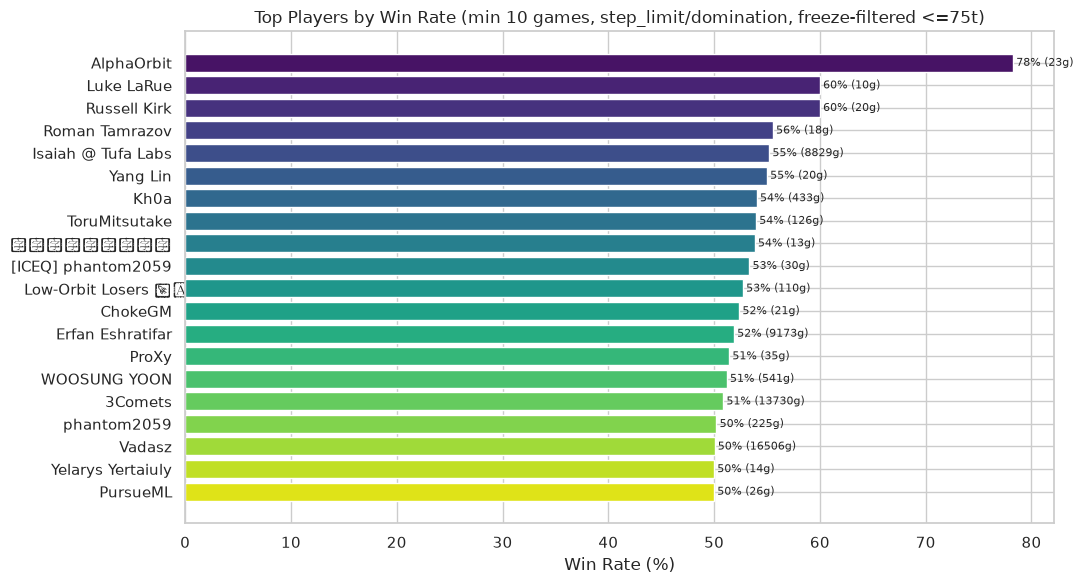

In [42]:
# So here we want to filter out the best accounting for awkward failure wins potentially  

# bring end_reason over from the episodes table

pl = players.merge(episodes[['episode_id', 'end_reason']], on='episode_id', how='left')
# keep only cleanly-decided games (toss agent_error; optionally toss step_limit too)
REASONS = ['step_limit', 'domination']            # or ['domination', 'mutual_destruction']
pl = pl[pl['end_reason'].isin(REASONS)]
# --- NEW: drop games where any participant froze / went abnormally silent ---
# opponent_silent_ticks = ticks the opponent was ALIVE but issued no action.
# Pick a threshold above the normal short-gap noise (median ~10, p75 ~23).
MAX_SILENT = 75                                   # or: pl['opponent_silent_ticks'].quantile(0.99)
ep_max_silent = pl.groupby('episode_id')['opponent_silent_ticks'].transform('max')
ep_any_froze  = pl.groupby('episode_id')['opponent_froze'].transform('max')   # never-acted / engine error
clean = (ep_max_silent <= MAX_SILENT) & (ep_any_froze == 0)
dropped = pl['episode_id'][~clean].nunique()
pl = pl[clean]
print(f"Dropped {dropped:,} games for freeze/long-silence (MAX_SILENT={MAX_SILENT}); "
      f"{pl['episode_id'].nunique():,} games remain.")
stats = pl.groupby('name').agg(
    games=('is_winner', 'count'), wins=('is_winner', 'sum')
).reset_index()
stats['win_rate'] = stats['wins'] / stats['games']
stats = stats[stats['games'] >= 10].sort_values('win_rate', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(range(len(stats)), stats['win_rate'] * 100,
        color=sns.color_palette('viridis', len(stats)))
ax.set_yticks(range(len(stats)))
ax.set_yticklabels(stats['name'])
ax.set_xlabel('Win Rate (%)')
ax.set_title(f"Top Players by Win Rate (min 10 games, {'/'.join(REASONS)}, "
             f"freeze-filtered <={MAX_SILENT}t)")
ax.invert_yaxis()
for i, (wr, g) in enumerate(zip(stats['win_rate'] * 100, stats['games'])):
    ax.text(wr + 0.3, i, f'{wr:.0f}% ({g}g)', va='center', fontsize=8)
plt.tight_layout(); plt.show()

/tmp/ipykernel_1182580/4227031164.py:21: UserWarning: Glyph 40065 (\N{CJK UNIFIED IDEOGRAPH-9C81}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/4227031164.py:21: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/4227031164.py:21: UserWarning: Glyph 32769 (\N{CJK UNIFIED IDEOGRAPH-8001}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/4227031164.py:21: UserWarning: Glyph 29239 (\N{CJK UNIFIED IDEOGRAPH-7237}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/4227031164.py:21: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/4227031164.py:21: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

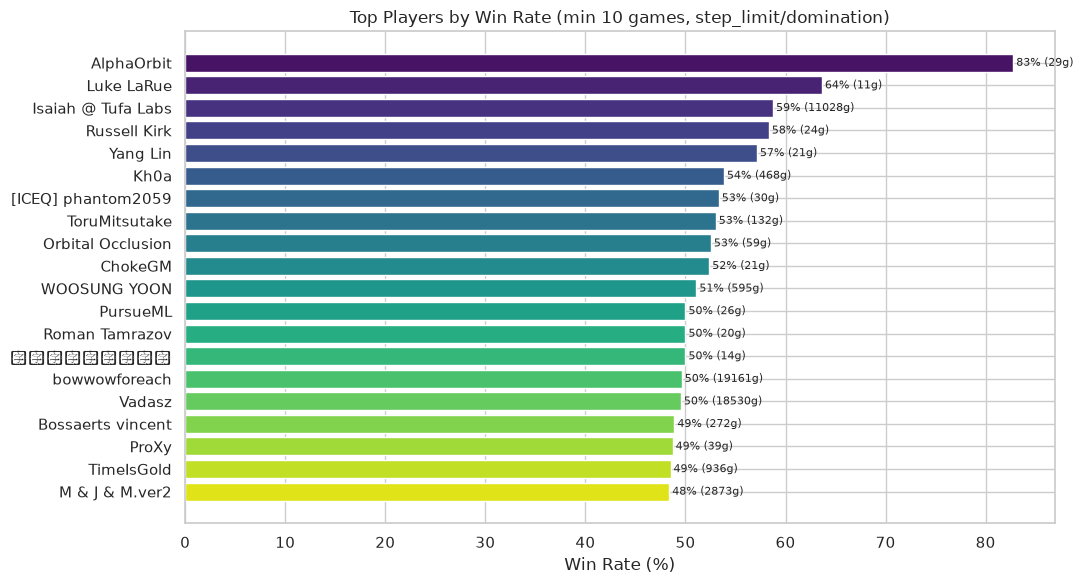

In [38]:
# bring end_reason over from the episodes table
pl = players.merge(episodes[['episode_id', 'end_reason']], on='episode_id', how='left')
# keep only cleanly-decided games (toss agent_error; optionally toss step_limit too)
REASONS = ['step_limit', 'domination']            # or ['domination', 'mutual_destruction']
pl = pl[pl['end_reason'].isin(REASONS)]
stats = pl.groupby('name').agg(
    games=('is_winner', 'count'), wins=('is_winner', 'sum')
).reset_index()
stats['win_rate'] = stats['wins'] / stats['games']
stats = stats[stats['games'] >= 10].sort_values('win_rate', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(range(len(stats)), stats['win_rate'] * 100,
        color=sns.color_palette('viridis', len(stats)))
ax.set_yticks(range(len(stats)))
ax.set_yticklabels(stats['name'])
ax.set_xlabel('Win Rate (%)')
ax.set_title(f"Top Players by Win Rate (min 10 games, {'/'.join(REASONS)})")
ax.invert_yaxis()
for i, (wr, g) in enumerate(zip(stats['win_rate'] * 100, stats['games'])):
    ax.text(wr + 0.3, i, f'{wr:.0f}% ({g}g)', va='center', fontsize=8)
plt.tight_layout(); plt.show()

/tmp/ipykernel_1182580/3754007449.py:17: UserWarning: Glyph 40065 (\N{CJK UNIFIED IDEOGRAPH-9C81}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3754007449.py:17: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3754007449.py:17: UserWarning: Glyph 32769 (\N{CJK UNIFIED IDEOGRAPH-8001}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3754007449.py:17: UserWarning: Glyph 29239 (\N{CJK UNIFIED IDEOGRAPH-7237}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3754007449.py:17: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1182580/3754007449.py:17: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

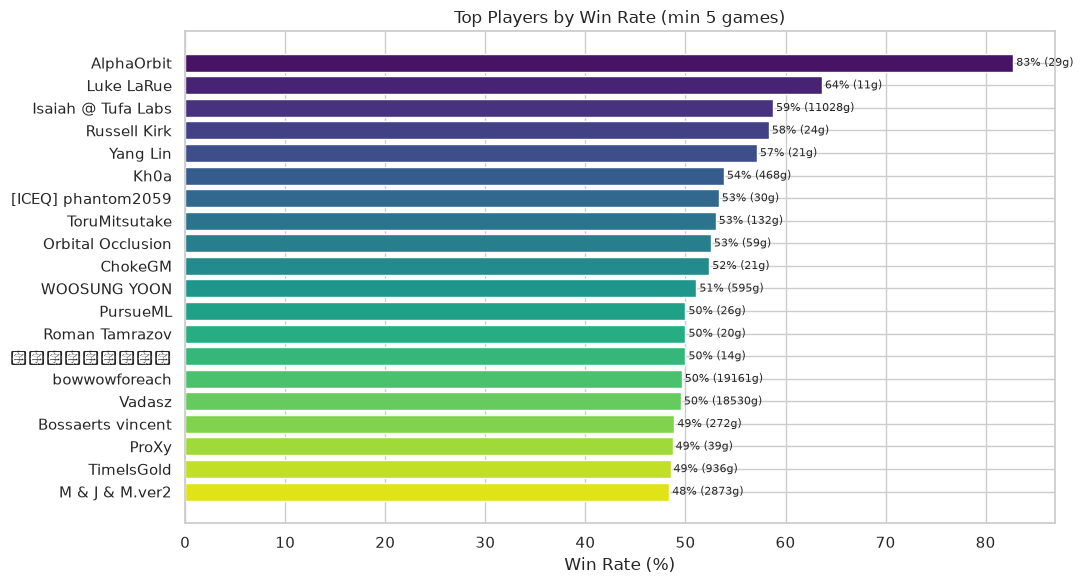

In [34]:
stats = players.groupby('name').agg(
    games=('is_winner','count'), wins=('is_winner','sum')
).reset_index()
stats['win_rate'] = stats['wins'] / stats['games']
stats = stats[stats['games'] >= 10].sort_values('win_rate', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(range(len(stats)), stats['win_rate']*100,
        color=sns.color_palette('viridis', len(stats)))
ax.set_yticks(range(len(stats)))
ax.set_yticklabels(stats['name'])
ax.set_xlabel('Win Rate (%)')
ax.set_title('Top Players by Win Rate (min 5 games)')
ax.invert_yaxis()
for i, (wr, g) in enumerate(zip(stats['win_rate']*100, stats['games'])):
    ax.text(wr + 0.3, i, f'{wr:.0f}% ({g}g)', va='center', fontsize=8)
plt.tight_layout(); plt.show()

### Winner vs Loser Economy Curves

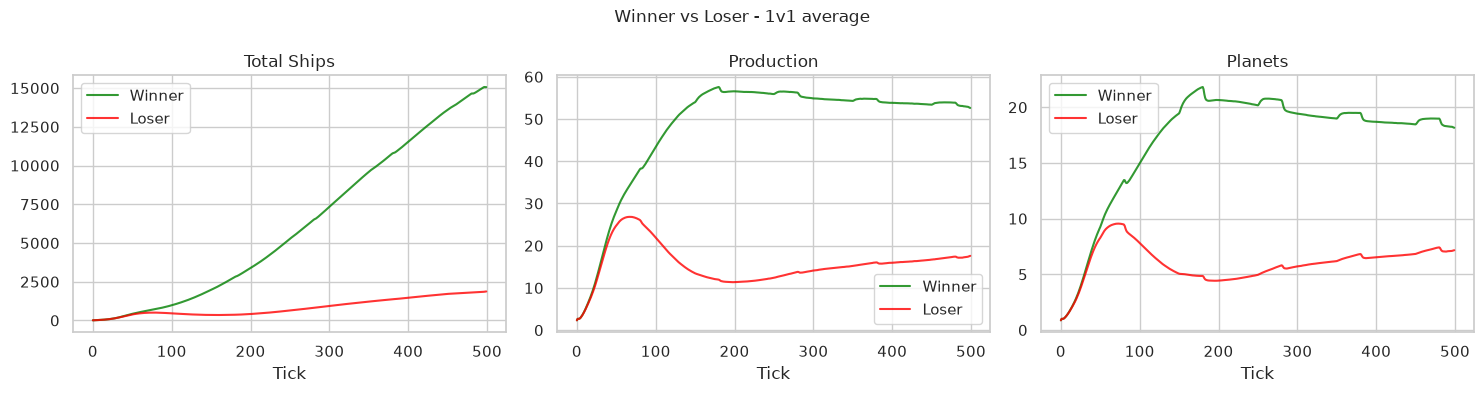

In [28]:
tw = ticks.merge(episodes[['episode_id','winner_slot','n_players']], on='episode_id')
tw['is_winner'] = (tw['slot'] == tw['winner_slot']).astype(int)
ticks_1v1 = tw[tw['n_players'] == 2]

curves = ticks_1v1.groupby(['tick','is_winner']).agg(
    ships=('total_ships','mean'),
    prod=('production','mean'),
    planets=('n_planets','mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for metric, title, ax in [
    ('ships', 'Total Ships', axes[0]),
    ('prod',  'Production',  axes[1]),
    ('planets','Planets',    axes[2]),
]:
    for w, label, color in [(1,'Winner','green'),(0,'Loser','red')]:
        d = curves[curves['is_winner']==w]
        ax.plot(d['tick'], d[metric], label=label, color=color, alpha=0.8)
    ax.set_xlabel('Tick'); ax.set_title(title); ax.legend()
plt.suptitle('Winner vs Loser - 1v1 average', fontsize=12)
plt.tight_layout(); plt.show()

### Key Finding: Volume > Fleet Size

The main differentiator between winners and losers is not **fleet size** but **send frequency**.
Winners ramp up to ~3â€“4 fleet launches per active tick in the late game; losers barely exceed 0.5.

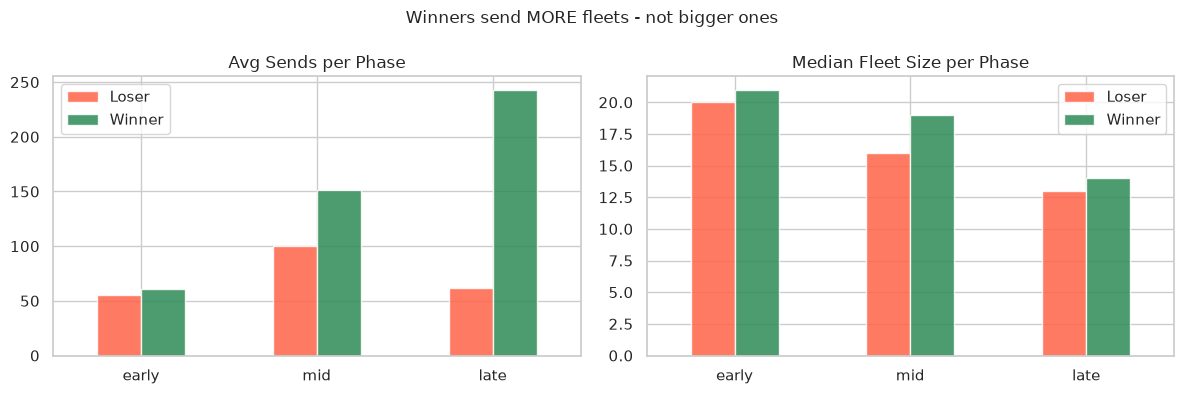

Sends per phase (avg):
        Loser  Winner
phase                
early   55.50   60.74
mid    100.25  151.15
late    61.36  243.12

Median fleet size:
       Loser  Winner
phase               
early   20.0    21.0
mid     16.0    19.0
late    13.0    14.0


In [29]:
ep_len = episodes.set_index('episode_id')['n_steps']

def phase(tick, n_steps):
    if tick < n_steps * 0.33: return 'early'
    if tick < n_steps * 0.66: return 'mid'
    return 'late'

act2 = actions.merge(episodes[['episode_id','winner_slot','n_players']], on='episode_id')
act2['is_winner'] = (act2['slot'] == act2['winner_slot']).astype(int)
act2 = act2[act2['n_players'] == 2].copy()
act2['game_length'] = act2['episode_id'].map(ep_len)
act2['phase'] = act2.apply(lambda r: phase(r['tick'], r['game_length']), axis=1)

sends = act2.groupby(['episode_id','slot','phase','is_winner']).size().reset_index(name='sends')
tempo = sends.groupby(['phase','is_winner'])['sends'].mean().unstack('is_winner')
tempo.columns = ['Loser','Winner']
tempo = tempo.reindex(['early','mid','late'])

fleet_sz = act2.groupby(['phase','is_winner'])['n_ships'].median().unstack('is_winner')
fleet_sz.columns = ['Loser','Winner']
fleet_sz = fleet_sz.reindex(['early','mid','late'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tempo.plot(kind='bar', ax=axes[0], color=['tomato','seagreen'], alpha=0.85)
axes[0].set_title('Avg Sends per Phase'); axes[0].set_xlabel('')
axes[0].legend(['Loser','Winner']); axes[0].tick_params(axis='x', rotation=0)

fleet_sz.plot(kind='bar', ax=axes[1], color=['tomato','seagreen'], alpha=0.85)
axes[1].set_title('Median Fleet Size per Phase'); axes[1].set_xlabel('')
axes[1].legend(['Loser','Winner']); axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Winners send MORE fleets - not bigger ones', fontsize=12)
plt.tight_layout(); plt.show()

print('Sends per phase (avg):'); print(tempo.round(2))
print(); print('Median fleet size:'); print(fleet_sz.round(1))

### Output Files

In [10]:
print('Output files written to /kaggle/working:')
for f in sorted(OUT_DIR.glob('*.parquet')):
    n = len(pq.read_table(f, columns=[pq.read_schema(f).names[0]]))
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:<30} {n:>10,} rows  {size_mb:>7.1f} MB')
total_mb = sum(f.stat().st_size for f in OUT_DIR.glob('*.parquet')) / 1e6
print(f'\nTotal: {total_mb:.0f} MB')
print()
print('All tables share episode_id. Example join:')
print("  ep = pd.read_parquet('episodes.parquet')")
print("  pl = pd.read_parquet('player_episodes.parquet')")
print("  ep.merge(pl, on='episode_id')")

Output files written to /kaggle/working:
  actions.parquet                   559,228 rows      4.1 MB
  episodes.parquet                      500 rows      0.0 MB
  planet_state.parquet            3,816,012 rows      5.7 MB
  player_episodes.parquet             1,406 rows      0.0 MB
  tick_summary.parquet              360,104 rows      2.7 MB

Total: 12 MB

All tables share episode_id. Example join:
  ep = pd.read_parquet('episodes.parquet')
  pl = pd.read_parquet('player_episodes.parquet')
  ep.merge(pl, on='episode_id')
